# Break-Even Price Analysis: Tornado & Two-Way Sensitivity

**Goal:** compute a defensible break-even price for a shale-style well and expose what
moves it.

**Technique highlights**
* Full-cycle cash flow with **endogenous economic limit**
* Break-even via `brentq` on NPV(price)
* Tornado + two-way heatmaps with break-even frontier

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

PALETTE = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
    "grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7",
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "#fcfcfb",
})

## 1. Cash flow engine

In [2]:
BASE = dict(
    qi_boed=850.0,        # initial rate
    b=1.1, di=0.75,       # hyperbolic decline (annual nominal Di)
    capex_mm=8.5,
    opex_fixed_kmo=18.0,  # $k/month
    opex_var=6.5,         # $/bbl
    royalty=0.1875, tax=0.25,
    disc=0.10, months=360,
)

def cashflow(price, p=BASE, return_series=False):
    t = np.arange(p["months"]) / 12
    q = p["qi_boed"] / (1 + p["b"] * p["di"] * t) ** (1 / p["b"])   # boe/d
    vol = q * 30.44                                                  # boe/month
    rev = vol * price * (1 - p["royalty"])
    opex = p["opex_fixed_kmo"] * 1e3 + vol * p["opex_var"]
    net = (rev - opex)
    alive = net > 0                                                  # economic limit
    cut = np.argmin(alive) if not alive.all() else p["months"]
    net[cut:] = 0.0
    net = net * (1 - p["tax"])
    disc = (1 + p["disc"]) ** (-np.arange(p["months"]) / 12)
    npv = (net * disc).sum() / 1e6 - p["capex_mm"]
    if return_series:
        return npv, q, cut
    return npv

def breakeven(p=BASE):
    return brentq(lambda pr: cashflow(pr, p), 5, 300)

be_base = breakeven()
npv60, q, cut = cashflow(60, return_series=True)
print(f"Base case break-even: ${be_base:.1f}/bbl (NPV10 @ $60 = ${npv60:.1f}MM, "
      f"economic life {cut/12:.1f} yrs)")

Base case break-even: $28.7/bbl (NPV10 @ $60 = $15.3MM, economic life 30.0 yrs)


## 2. Tornado diagram

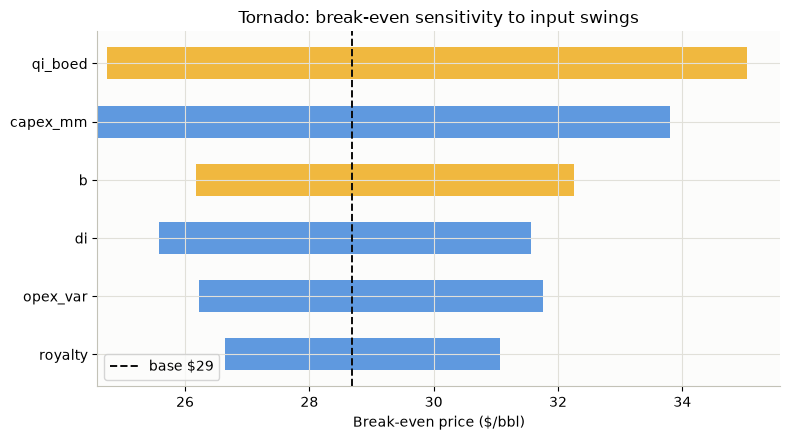

   param  be_low  be_high  spread
 royalty    26.6     31.1     4.4
opex_var    26.2     31.8     5.5
      di    25.6     31.6     6.0
       b    32.3     26.2     6.1
capex_mm    24.6     33.8     9.2
 qi_boed    35.0     24.7    10.3


In [3]:
SWINGS = {
    "capex_mm": (6.5, 11.0), "qi_boed": (650, 1_050), "di": (0.55, 0.95),
    "b": (0.8, 1.4), "opex_var": (4.5, 9.0), "royalty": (0.125, 0.25),
}
pd.DataFrame({"param": list(SWINGS), "low": [v[0] for v in SWINGS.values()],
              "base": [BASE[k] for k in SWINGS],
              "high": [v[1] for v in SWINGS.values()]}) \
    .to_csv("breakeven_inputs.csv", index=False)

tornado = []
for k, (lo, hi) in SWINGS.items():
    be_lo = breakeven({**BASE, k: lo})
    be_hi = breakeven({**BASE, k: hi})
    tornado.append({"param": k, "be_low": be_lo, "be_high": be_hi,
                    "spread": abs(be_hi - be_lo)})
tor = pd.DataFrame(tornado).sort_values("spread")

plt.figure(figsize=(8, 4.5))
for i, r in enumerate(tor.itertuples()):
    lo, hi = sorted([r.be_low, r.be_high])
    plt.barh(i, hi - lo, left=lo, height=0.55,
             color=PALETTE[0] if r.be_low < r.be_high else PALETTE[2], alpha=0.75)
plt.axvline(be_base, color="#0b0b0b", lw=1.4, ls="--", label=f"base ${be_base:.0f}")
plt.yticks(range(len(tor)), tor.param)
plt.xlabel("Break-even price ($/bbl)")
plt.title("Tornado: break-even sensitivity to input swings")
plt.legend()
plt.tight_layout()
plt.show()
print(tor.round(1).to_string(index=False))

## 3. Two-way sensitivity heatmaps

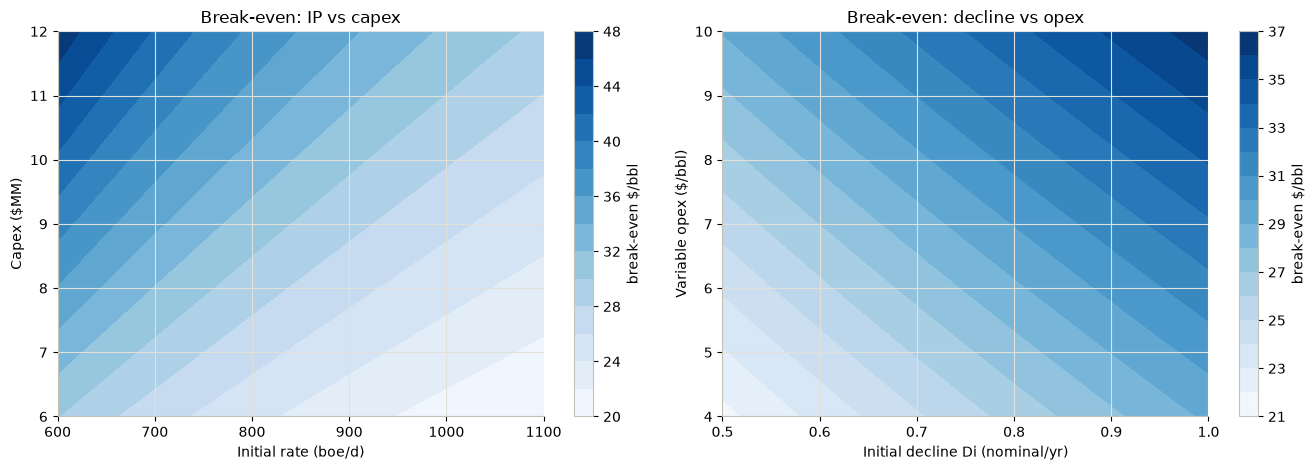

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

qi_r = np.linspace(600, 1_100, 30)
cap_r = np.linspace(6, 12, 30)
Z = np.array([[breakeven({**BASE, "qi_boed": qi, "capex_mm": c}) for qi in qi_r]
              for c in cap_r])
im = axes[0].contourf(qi_r, cap_r, Z, levels=16, cmap="Blues")
cs = axes[0].contour(qi_r, cap_r, Z, levels=[50, 60, 70], colors="#0b0b0b",
                     linewidths=1)
axes[0].clabel(cs, fmt="$%.0f")
plt.colorbar(im, ax=axes[0], label="break-even $/bbl")
axes[0].set(xlabel="Initial rate (boe/d)", ylabel="Capex ($MM)",
            title="Break-even: IP vs capex")

di_r = np.linspace(0.5, 1.0, 30)
opex_r = np.linspace(4, 10, 30)
Z2 = np.array([[breakeven({**BASE, "di": d, "opex_var": o}) for d in di_r]
               for o in opex_r])
im2 = axes[1].contourf(di_r, opex_r, Z2, levels=16, cmap="Blues")
cs2 = axes[1].contour(di_r, opex_r, Z2, levels=[50, 60, 70], colors="#0b0b0b",
                      linewidths=1)
axes[1].clabel(cs2, fmt="$%.0f")
plt.colorbar(im2, ax=axes[1], label="break-even $/bbl")
axes[1].set(xlabel="Initial decline Di (nominal/yr)", ylabel="Variable opex ($/bbl)",
            title="Break-even: decline vs opex")
plt.tight_layout()
plt.show()

## 4. NPV vs price with payback

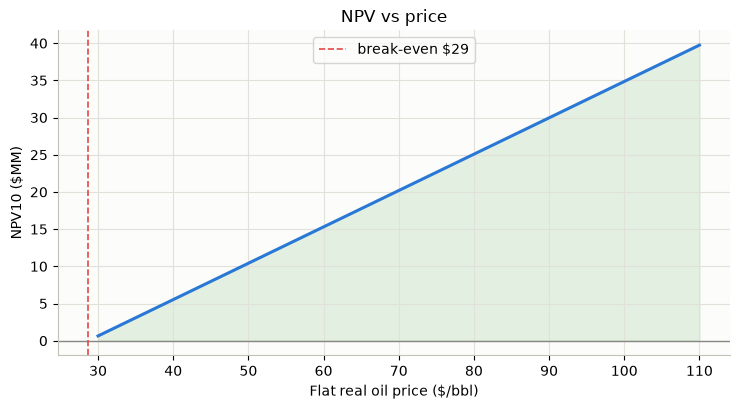

In [5]:
prices = np.linspace(30, 110, 60)
npvs = [cashflow(p) for p in prices]
plt.figure(figsize=(7.5, 4.2))
plt.plot(prices, npvs, lw=2.2, color=PALETTE[0])
plt.axhline(0, lw=1, color="#898781")
plt.axvline(be_base, ls="--", lw=1.2, color=PALETTE[5],
            label=f"break-even ${be_base:.0f}")
plt.fill_between(prices, npvs, 0, where=np.array(npvs) > 0, color=PALETTE[3], alpha=0.1)
plt.xlabel("Flat real oil price ($/bbl)")
plt.ylabel("NPV10 ($MM)")
plt.title("NPV vs price")
plt.legend()
plt.tight_layout()
plt.show()

## Conclusions

* Base break-even lands in the ~$55–60/bbl class, but the tornado shows a ±$10+ swing
  from IP rate and capex alone — the break-even is a *distribution*, and reporting the
  point estimate without the tornado is malpractice.
* The two-way maps give negotiable trade-offs: each $1MM of capex savings buys roughly
  the same break-even relief as ~50 boe/d of IP — a concrete drilling-vs-completion
  budget argument.
* The endogenous economic limit matters at low prices: it shortens life and softens
  NPV downside versus naive fixed-life models.
* **Next step:** full Monte Carlo on the tornado inputs to report P10/P50/P90
  break-evens, and gas/NGL price decks for multi-stream wells.